<a href="https://colab.research.google.com/github/Pratyakshk05/deep-learning/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wandb -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import wandb

In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pratyakshk05 (pratyakshk05-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
BATCH_SIZE = 128
EPOCHS = 20
LR = 0.001
LATENT_DIM = 16
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size,val_size,test_size])

train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_ds,batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE)

100%|██████████| 26.4M/26.4M [00:00<00:00, 111MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.69MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 56.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.70MB/s]


In [6]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,784),
            nn.Sigmoid()
        )

    def forward(self,x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)

        self.mu = nn.Linear(128,latent_dim)
        self.logvar = nn.Linear(128,latent_dim)

        self.fc3 = nn.Linear(latent_dim,128)
        self.fc4 = nn.Linear(128,256)
        self.fc5 = nn.Linear(256,784)

    def encode(self,x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self,mu,logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self,z):
        h = torch.relu(self.fc3(z))
        h = torch.relu(self.fc4(h))
        return torch.sigmoid(self.fc5(h))

    def forward(self,x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu,logvar)
        out = self.decode(z)
        return out, mu, logvar

In [8]:
def vae_loss(recon,x,mu,logvar):
    BCE = nn.functional.binary_cross_entropy(recon,x,reduction='sum')

    KL = -0.5 * torch.sum(1+logvar-mu.pow(2)-logvar.exp())

    return BCE + KL

In [9]:
def train_model(model, optimizer, model_type='AE'):

    wandb.init(project="Autoencoder-VAE",reinit=True)

    for epoch in range(EPOCHS):

        model.train()
        train_loss=0

        for images,_ in train_loader:

            images = images.to(DEVICE)
            flat = images.view(-1,784)

            optimizer.zero_grad()

            if model_type=='AE':
                output = model(images)
                loss = nn.functional.binary_cross_entropy(output,flat)

            else:
                output,mu,logvar = model(flat)
                loss = vae_loss(output,flat,mu,logvar)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        wandb.log({"Train Loss":train_loss/len(train_loader)})

        print(f"Epoch {epoch+1}: Loss={train_loss/len(train_loader):.4f}")

    wandb.finish()

In [10]:
ae = Autoencoder(LATENT_DIM).to(DEVICE)

optimizer = optim.Adam(ae.parameters(),lr=LR)

train_model(ae,optimizer,'AE')

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1: Loss=0.3659
Epoch 2: Loss=0.3120
Epoch 3: Loss=0.3035
Epoch 4: Loss=0.2986
Epoch 5: Loss=0.2957
Epoch 6: Loss=0.2936
Epoch 7: Loss=0.2917
Epoch 8: Loss=0.2901
Epoch 9: Loss=0.2888
Epoch 10: Loss=0.2876
Epoch 11: Loss=0.2866
Epoch 12: Loss=0.2857
Epoch 13: Loss=0.2850
Epoch 14: Loss=0.2844
Epoch 15: Loss=0.2837
Epoch 16: Loss=0.2832
Epoch 17: Loss=0.2827
Epoch 18: Loss=0.2823
Epoch 19: Loss=0.2819
Epoch 20: Loss=0.2816


Train Loss,█▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Train Loss,0.28159


In [12]:
vae = VAE(LATENT_DIM).to(DEVICE)

optimizer = optim.Adam(vae.parameters(),lr=LR)

train_model(vae,optimizer,'VAE')

Epoch 1: Loss=39204.7736
Epoch 2: Loss=33377.8581
Epoch 3: Loss=32418.9891
Epoch 4: Loss=31947.0936
Epoch 5: Loss=31700.4582
Epoch 6: Loss=31542.1670
Epoch 7: Loss=31415.8389
Epoch 8: Loss=31314.5207
Epoch 9: Loss=31223.0106
Epoch 10: Loss=31156.5134
Epoch 11: Loss=31091.4212
Epoch 12: Loss=31042.5226
Epoch 13: Loss=30990.6261
Epoch 14: Loss=30946.8238
Epoch 15: Loss=30914.5904
Epoch 16: Loss=30875.3818
Epoch 17: Loss=30843.5575
Epoch 18: Loss=30817.4356
Epoch 19: Loss=30797.0874
Epoch 20: Loss=30773.5395


Train Loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
Train Loss,30773.53954


In [14]:
def interpolate(model,img1,img2,steps=10):

    model.eval()

    with torch.no_grad():

        z1 = model.encoder(img1.unsqueeze(0).to(DEVICE))
        z2 = model.encoder(img2.unsqueeze(0).to(DEVICE))

        interpolations=[]

        for alpha in np.linspace(0,1,steps):

            z = (1-alpha)*z1 + alpha*z2

            out = model.decoder(z)

            interpolations.append(out.cpu().view(28,28))

    plt.figure(figsize=(15,2))

    for i,img in enumerate(interpolations):
        plt.subplot(1,steps,i+1)
        plt.imshow(img,cmap='gray')

    plt.show()

In [13]:
def show_reconstruction(model,loader,model_type='AE'):
    model.eval()

    images,_ = next(iter(loader))
    images = images.to(DEVICE)

    with torch.no_grad():

        if model_type=='AE':
            recon = model(images)

        else:
            recon,_,_ = model(images.view(-1,784))

    fig,ax = plt.subplots(2,6,figsize=(12,4))

    for i in range(6):
        ax[0,i].imshow(images[i].cpu().squeeze(),cmap='gray')
        ax[1,i].imshow(recon[i].cpu().view(28,28),cmap='gray')

    plt.show()

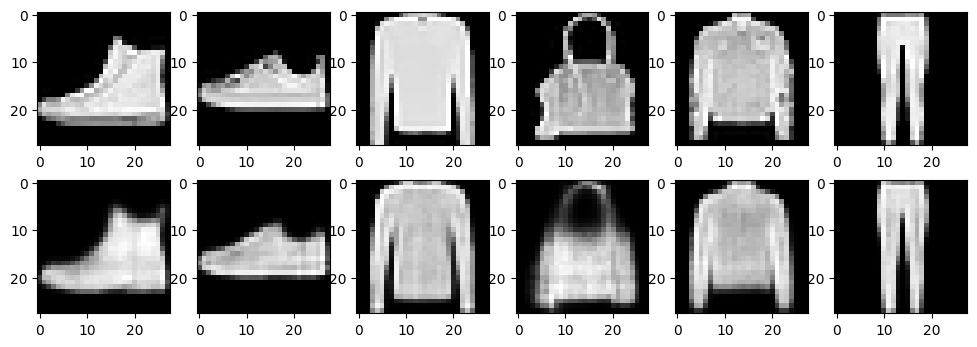

In [16]:
show_reconstruction(ae, test_loader, 'AE')

In [15]:
latent_dims = [2,8,16,32]

for dim in latent_dims:

    print("Training for latent dim =",dim)

    model = Autoencoder(dim).to(DEVICE)

    optimizer = optim.Adam(model.parameters(),lr=LR)

    train_model(model,optimizer,'AE')

Training for latent dim = 2


Epoch 1: Loss=0.3724
Epoch 2: Loss=0.3338
Epoch 3: Loss=0.3304
Epoch 4: Loss=0.3286
Epoch 5: Loss=0.3273
Epoch 6: Loss=0.3264
Epoch 7: Loss=0.3253
Epoch 8: Loss=0.3241
Epoch 9: Loss=0.3236
Epoch 10: Loss=0.3228
Epoch 11: Loss=0.3223
Epoch 12: Loss=0.3216
Epoch 13: Loss=0.3215
Epoch 14: Loss=0.3210
Epoch 15: Loss=0.3205
Epoch 16: Loss=0.3204
Epoch 17: Loss=0.3201
Epoch 18: Loss=0.3197
Epoch 19: Loss=0.3198
Epoch 20: Loss=0.3192


Train Loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
Train Loss,0.31922


Training for latent dim = 8


Epoch 1: Loss=0.3679
Epoch 2: Loss=0.3118
Epoch 3: Loss=0.3033
Epoch 4: Loss=0.2989
Epoch 5: Loss=0.2963
Epoch 6: Loss=0.2944
Epoch 7: Loss=0.2930
Epoch 8: Loss=0.2918
Epoch 9: Loss=0.2908
Epoch 10: Loss=0.2900
Epoch 11: Loss=0.2893
Epoch 12: Loss=0.2887
Epoch 13: Loss=0.2882
Epoch 14: Loss=0.2878
Epoch 15: Loss=0.2875
Epoch 16: Loss=0.2871
Epoch 17: Loss=0.2868
Epoch 18: Loss=0.2866
Epoch 19: Loss=0.2863
Epoch 20: Loss=0.2860


...

Epoch 1: Loss=0.3626
Epoch 2: Loss=0.3110
Epoch 3: Loss=0.3035
Epoch 4: Loss=0.2990
Epoch 5: Loss=0.2955
Epoch 6: Loss=0.2929
Epoch 7: Loss=0.2908
Epoch 8: Loss=0.2892
Epoch 9: Loss=0.2879
Epoch 10: Loss=0.2868
Epoch 11: Loss=0.2858
Epoch 12: Loss=0.2851
Epoch 13: Loss=0.2844
Epoch 14: Loss=0.2838
Epoch 15: Loss=0.2833
Epoch 16: Loss=0.2828
Epoch 17: Loss=0.2824
Epoch 18: Loss=0.2820
Epoch 19: Loss=0.2817
Epoch 20: Loss=0.2813


Train Loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
Train Loss,0.28133


Training for latent dim = 32


Epoch 1: Loss=0.3660
Epoch 2: Loss=0.3121
Epoch 3: Loss=0.3043
Epoch 4: Loss=0.2992
Epoch 5: Loss=0.2957
Epoch 6: Loss=0.2931
Epoch 7: Loss=0.2910
Epoch 8: Loss=0.2893
Epoch 9: Loss=0.2878
Epoch 10: Loss=0.2867
Epoch 11: Loss=0.2855
Epoch 12: Loss=0.2846
Epoch 13: Loss=0.2838
Epoch 14: Loss=0.2832
Epoch 15: Loss=0.2826
Epoch 16: Loss=0.2820
Epoch 17: Loss=0.2815
Epoch 18: Loss=0.2811
Epoch 19: Loss=0.2806
Epoch 20: Loss=0.2803


Train Loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Train Loss,0.28026


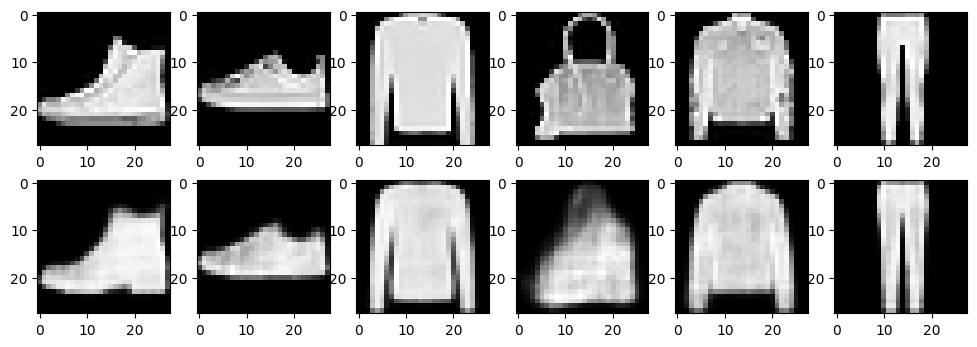

In [17]:
show_reconstruction(vae, test_loader, 'VAE')

In [18]:
optimizers = {
    "SGD": optim.SGD,
    "RMSprop": optim.RMSprop,
    "Adam": optim.Adam
}

for name,opt in optimizers.items():

    print("Optimizer:",name)

    model = Autoencoder(16).to(DEVICE)

    optimizer = opt(model.parameters(),lr=LR)

    train_model(model,optimizer,'AE')

Optimizer: SGD


Epoch 1: Loss=0.6936
Epoch 2: Loss=0.6935
Epoch 3: Loss=0.6934
Epoch 4: Loss=0.6934
Epoch 5: Loss=0.6933
Epoch 6: Loss=0.6932
Epoch 7: Loss=0.6931
Epoch 8: Loss=0.6930
Epoch 9: Loss=0.6929
Epoch 10: Loss=0.6928
Epoch 11: Loss=0.6928
Epoch 12: Loss=0.6927
Epoch 13: Loss=0.6926
Epoch 14: Loss=0.6925
Epoch 15: Loss=0.6924
Epoch 16: Loss=0.6923
Epoch 17: Loss=0.6922
Epoch 18: Loss=0.6921
Epoch 19: Loss=0.6921
Epoch 20: Loss=0.6920


Train Loss,██▇▇▇▆▆▅▅▅▄▄▄▃▃▂▂▂▁▁
Train Loss,0.69197


Optimizer: RMSprop


Epoch 1: Loss=0.3667
Epoch 2: Loss=0.3196
Epoch 3: Loss=0.3111
Epoch 4: Loss=0.3063
Epoch 5: Loss=0.3025
Epoch 6: Loss=0.2997
Epoch 7: Loss=0.2976
Epoch 8: Loss=0.2958
Epoch 9: Loss=0.2943
Epoch 10: Loss=0.2928
Epoch 11: Loss=0.2917
Epoch 12: Loss=0.2907
Epoch 13: Loss=0.2897
Epoch 14: Loss=0.2890
Epoch 15: Loss=0.2883
Epoch 16: Loss=0.2877
Epoch 17: Loss=0.2872
Epoch 18: Loss=0.2867
Epoch 19: Loss=0.2863
Epoch 20: Loss=0.2858


Train Loss,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
Train Loss,0.28582


Optimizer: Adam


Epoch 1: Loss=0.3659
Epoch 2: Loss=0.3128
Epoch 3: Loss=0.3058
Epoch 4: Loss=0.3003
Epoch 5: Loss=0.2970
Epoch 6: Loss=0.2945
Epoch 7: Loss=0.2922
Epoch 8: Loss=0.2906
Epoch 9: Loss=0.2891
Epoch 10: Loss=0.2878
Epoch 11: Loss=0.2867
Epoch 12: Loss=0.2858
Epoch 13: Loss=0.2851
Epoch 14: Loss=0.2843
Epoch 15: Loss=0.2836
Epoch 16: Loss=0.2830
Epoch 17: Loss=0.2825
Epoch 18: Loss=0.2821
Epoch 19: Loss=0.2818
Epoch 20: Loss=0.2813


Train Loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Train Loss,0.28133


In [19]:
torch.save(ae.state_dict(),"autoencoder.pth")
torch.save(vae.state_dict(),"vae.pth")

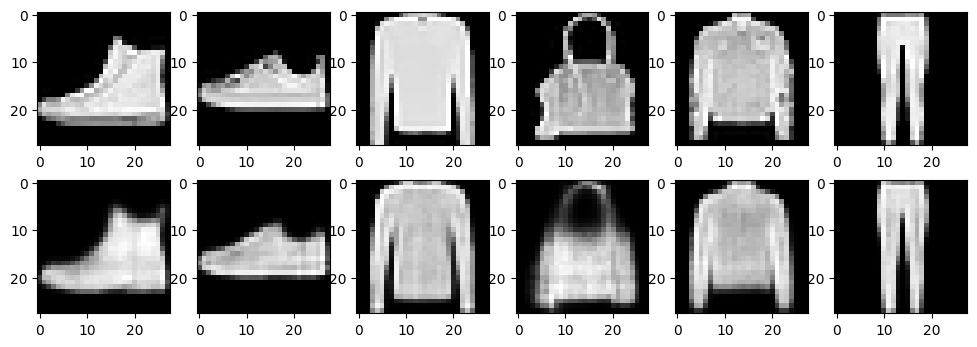

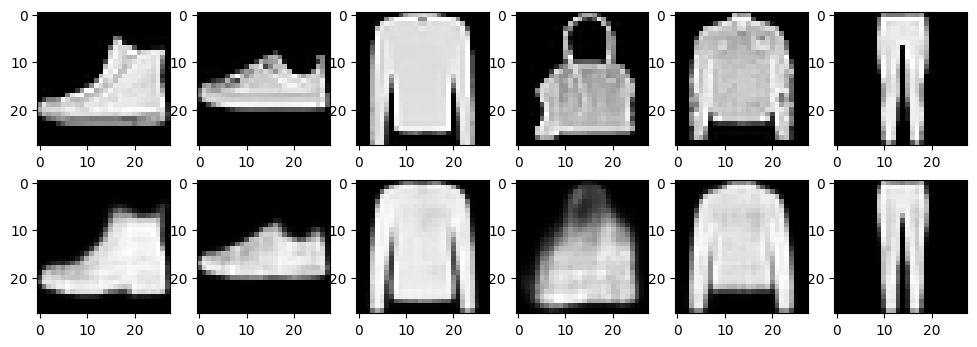

In [20]:
show_reconstruction(ae, test_loader, 'AE')
show_reconstruction(vae, test_loader, 'VAE')

In [23]:
def plot_latent_space(model):
    model.eval()
    zs=[]
    labels=[]

    with torch.no_grad():
        for images,lbl in test_loader:
            images = images.to(DEVICE)

            z = model.encoder(images)

            zs.append(z.cpu())
            labels.append(lbl)

    zs=torch.cat(zs)
    labels=torch.cat(labels)

    plt.figure(figsize=(8,6))
    plt.scatter(zs[:,0],zs[:,1],c=labels,cmap='tab10')
    plt.colorbar()
    plt.show()

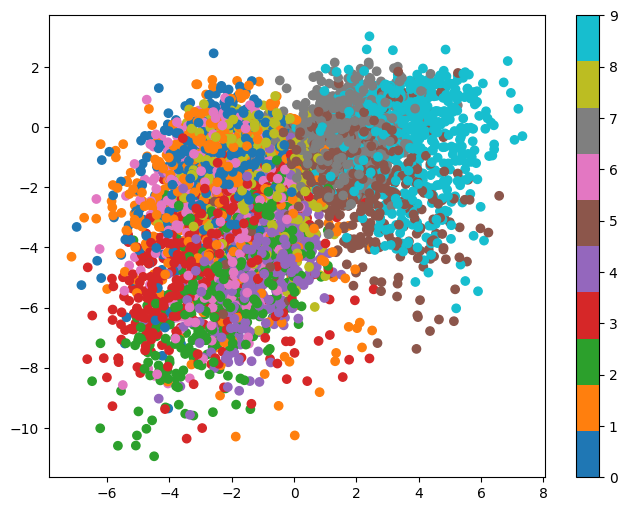

In [24]:
plot_latent_space(ae)

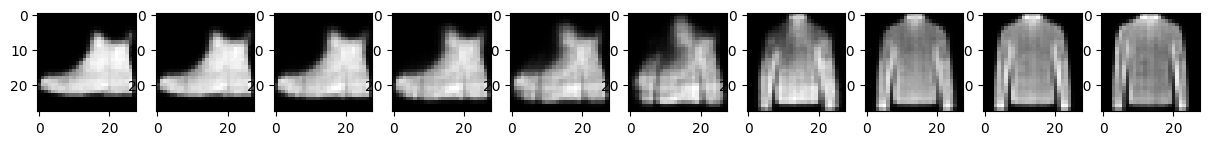

In [25]:
img1,_ = test_ds[0]
img2,_ = test_ds[10]

interpolate(ae,img1,img2)

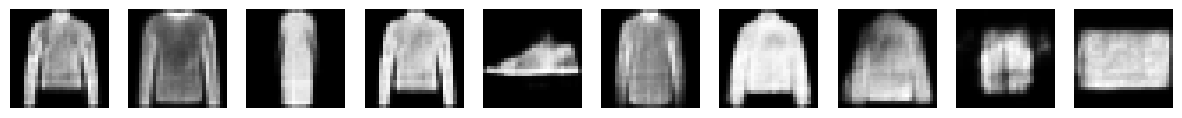

In [26]:
with torch.no_grad():
    z = torch.randn(10,LATENT_DIM).to(DEVICE)
    generated = vae.decode(z)

fig,ax = plt.subplots(1,10,figsize=(15,2))

for i in range(10):
    ax[i].imshow(generated[i].cpu().view(28,28),cmap='gray')
    ax[i].axis('off')

plt.show()

In [27]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
